In [8]:
import pandas as pd

df_clean = pd.read_csv("../data/processed/sephora_clean.csv")
df_clean.head()

/var/folders/1k/bsvhbsyn1gn8zm9g3p5pzyrc0000gn/T/ipykernel_18090/1326429665.py:3: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df_clean = pd.read_csv("../data/processed/sephora_clean.csv")


,author_id,rating,is_recommended,helpfulness,total_feedback_count,total_neg_feedback_count,total_pos_feedback_count,submission_time,review_text,review_title,...,new,online_only,out_of_stock,sephora_exclusive,highlights,primary_category,secondary_category,tertiary_category,child_count,rating_category
0,1741593524,5,1.0,1.0,2,0,2,2023-02-01,i use this with the nudestix citrus clean balm...,Taught me how to double cleanse!,...,0,1,0,0,['Clean at Sephora'],Skincare,Cleansers,NaN,0,positive
1,31423088263,1,0.0,NaN,0,0,0,2023-03-21,i bought this lip mask after reading the revie...,Disappointed,...,0,0,0,1,"['allure 2019 Best of Beauty Award Winner', 'C...",Skincare,Lip Balms & Treatments,NaN,3,negative
2,5061282401,5,1.0,NaN,0,0,0,2023-03-21,my review title says it all i get so excited t...,New Favorite Routine,...,0,0,0,1,"['allure 2019 Best of Beauty Award Winner', 'C...",Skincare,Lip Balms & Treatments,NaN,3,positive
3,6083038851,5,1.0,NaN,0,0,0,2023-03-20,ive always loved this formula for a long time ...,Can't go wrong with any of them,...,0,0,0,1,"['allure 2019 Best of Beauty Award Winner', 'C...",Skincare,Lip Balms & Treatments,NaN,3,positive
4,47056667835,5,1.0,NaN,0,0,0,2023-03-20,if you have dry cracked lips this is a must ha...,A must have !!!,...,0,0,0,1,"['allure 2019 Best of Beauty Award Winner', 'C...",Skincare,Lip Balms & Treatments,NaN,3,positive


 1- RATING DISTRIBUTION

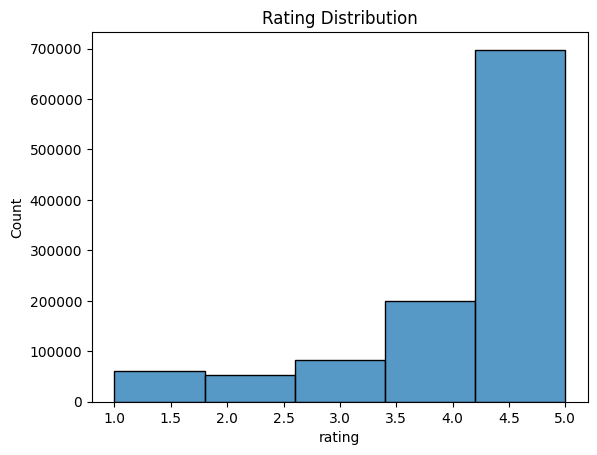

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df_clean["rating"], bins=5)
plt.title("Rating Distribution")
plt.show()

📊 2) IS_RECOMMENDED ANALİZİ

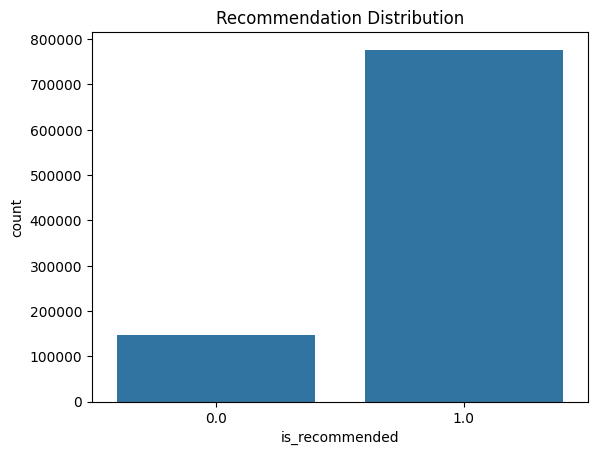

In [10]:
sns.countplot(x="is_recommended", data=df_clean)
plt.title("Recommendation Distribution")
plt.show()

📊 3) PRICE vs RATING

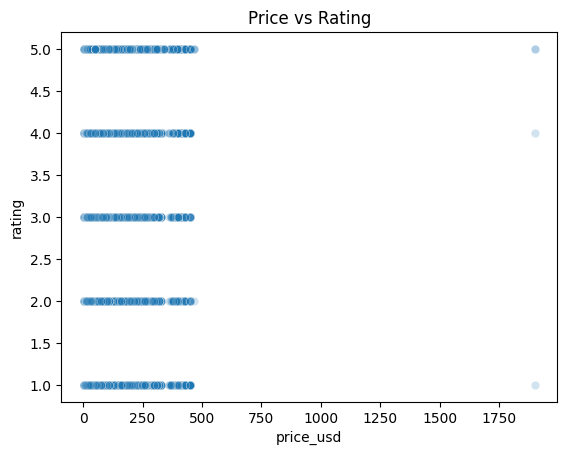

In [11]:
sns.scatterplot(x="price_usd", y="rating", data=df_clean, alpha=0.2)
plt.title("Price vs Rating")
plt.show()

4) CATEGORY ANALYSIS

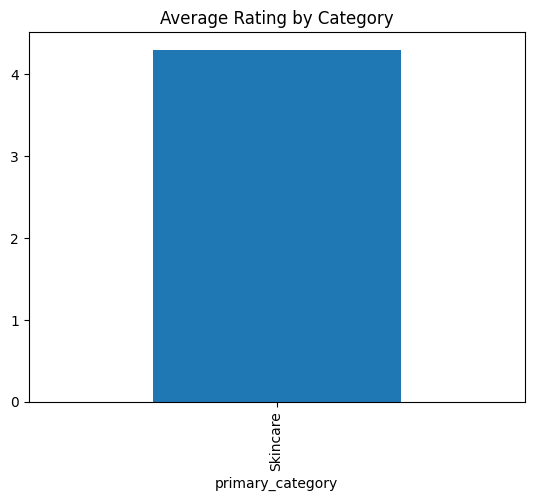

In [12]:
df_clean.groupby("primary_category")["rating"].mean().sort_values().plot(kind="bar")
plt.title("Average Rating by Category")
plt.show()

📊 5) TOP PRODUCTS

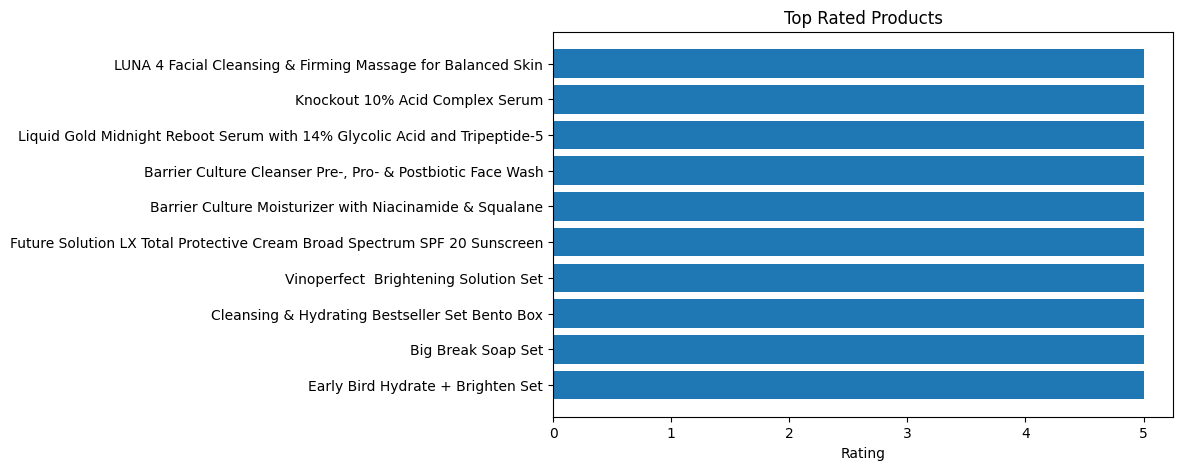

In [19]:
import matplotlib.pyplot as plt

top_products = (
    df_clean.groupby("product_name")["rating"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

plt.figure(figsize=(8,5))
plt.barh(top_products["product_name"], top_products["rating"])
plt.title("Top Rated Products")
plt.xlabel("Rating")
plt.gca().invert_yaxis()
plt.show()

📊 8) MOST REVIEWED PRODUCTS

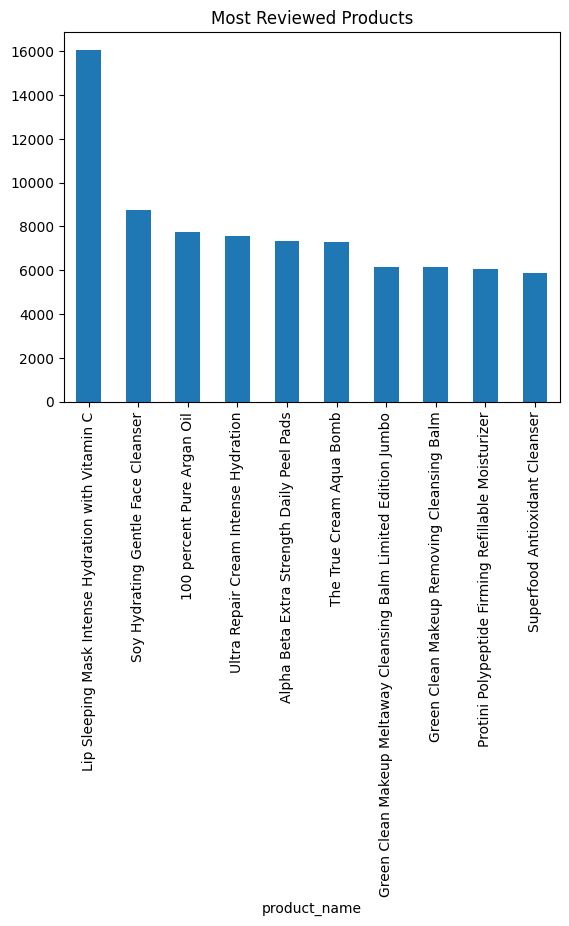

In [20]:
df_clean["product_name"].value_counts().head(10).plot(kind="bar")
plt.title("Most Reviewed Products")
plt.show()

In [21]:
#numeric kolonların seçilmesi
num_cols = df_clean.select_dtypes(include=["int64", "float64"])
num_cols.columns

Index(['rating', 'is_recommended', 'helpfulness', 'total_feedback_count',
       'total_neg_feedback_count', 'total_pos_feedback_count', 'price_usd',
       'brand_id', 'loves_count', 'reviews', 'limited_edition', 'new',
       'online_only', 'out_of_stock', 'sephora_exclusive', 'child_count'],
      dtype='object')

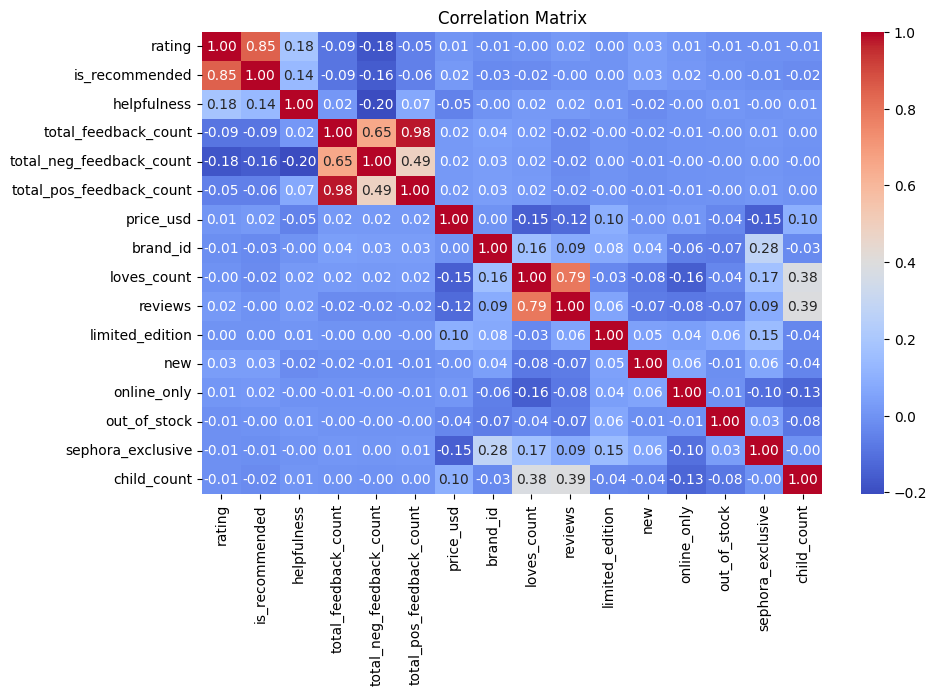

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = num_cols.corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()